<a href="https://colab.research.google.com/github/sohailarizk/rainfall-prediction-project/blob/main/League%20of%20legends%20predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%time
%pip install pandas scikit-learn matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.4 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.11.0+cpu
    Uninstalling torch-2.11.0+cpu:
      Successfully uninstalled torch-2.11.0+cpu
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.26.0+cpu
    Uninstalling torchvision-0.26.0+cpu:
      Successfully uninstalled torchvision-0.26.0+cpu
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 2.11.0+cpu
    Uninstalling torchaudio-2.11.0+cpu:
      Successfully uninstalled torchaudio-2.11.0+cpu
CPU times: user 5.45 s, sys: 1.27 s, total: 6.72 s
Wall time: 1min 38s


In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import os
print("Files in current directory:")
print(os.listdir('.'))


Files in current directory:
['.config', 'sample_data']


In [ ]:
# ============================================================
# EXERCISE 1: Data Loading and Preprocessing
# ============================================================

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import urllib.request
import os

# Download the dataset if it doesn't exist
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv"
filename = 'league_of_legends_data_large.csv'

if not os.path.exists(filename):
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete!")
else:
    print(f"{filename} already exists.")

# 1. Load the dataset
data = pd.read_csv(filename)

# Display basic information about the dataset
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"\nDataset shape: {data.shape}")
print(f"\nFirst few rows:")
print(data.head())
print(f"\nColumn names:")
print(data.columns.tolist())
print(f"\nDataset info:")
print(data.info())

# 2. Split data into features and target
X = data.drop('win', axis=1)
y = data['win']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 3. Split the Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Add stratification to maintain class balance
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# 4. Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier viewing (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nFeature scaling completed!")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

# 5. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

print("\nData conversion to PyTorch tensors completed!")
print(f"X_train tensor shape: {X_train_tensor.shape}")
print(f"y_train tensor shape: {y_train_tensor.shape}")
print(f"X_test tensor shape: {X_test_tensor.shape}")
print(f"y_test tensor shape: {y_test_tensor.shape}")

# Verify the data types
print(f"\nData types:")
print(f"X_train: {X_train_tensor.dtype}")
print(f"y_train: {y_train_tensor.dtype}")

# Check for any missing values
print(f"\nMissing values in training set: {X_train.isnull().sum().sum()}")
print(f"Missing values in testing set: {X_test.isnull().sum().sum()}")

# Display class distribution
print(f"\nClass distribution in training set:")
print(f"Win (1): {y_train.sum()}")
print(f"Loss (0): {len(y_train) - y_train.sum()}")

print(f"\nClass distribution in testing set:")
print(f"Win (1): {y_test.sum()}")
print(f"Loss (0): {len(y_test) - y_test.sum()}")

print("\n" + "="*60)
print("✅ EXERCISE 1 COMPLETED SUCCESSFULLY!")
print("="*60)

Download complete!

DATASET INFORMATION

Dataset shape: (1000, 9)

First few rows:
   win  kills  deaths  assists  gold_earned   cs  wards_placed  wards_killed  \
0    0     16       6       19        17088  231            11             7   
1    1      8       8        5        14865  259            10             2   
2    0      0      17       11        15919  169            14             5   
3    0     19      11        1        11534  264            14             3   
4    0     12       7        6        18926  124            15             7   

   damage_dealt  
0         15367  
1         38332  
2         24642  
3         15789  
4         40268  

Column names:
['win', 'kills', 'deaths', 'assists', 'gold_earned', 'cs', 'wards_placed', 'wards_killed', 'damage_dealt']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0  

In [ ]:
#Exercise 2
import torch
import torch.nn as nn
import torch.optim as optim

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):

        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        linear_output = self.linear(x)
        output = torch.sigmoid(linear_output)
        return output

input_dim = X_train.shape[1]
print(f" Number of input features: {input_dim}")

model = LogisticRegressionModel(input_dim)
print(f" Model initialized successfully!")
print(f"Model architecture:\n{model}")

print(f"\n Model parameters:")
criterion = nn.BCELoss()
print(f"\n✅ Loss function: Binary Cross-Entropy Loss (BCELoss)")
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
print(f"✅ Optimizer: Stochastic Gradient Descent (SGD)")
print(f"   Learning rate: {learning_rate}")
print(f"\n🔧 Optimizer configuration:")
print(f"   Optimizer type: {type(optimizer).__name__}")
print(f"   Parameters being optimized: {len(optimizer.param_groups)} group(s)")

print(f"\n✅ Model ready for training!")
print(f"   - Model: {model.__class__.__name__}")
print(f"   - Loss function: {criterion.__class__.__name__}")
print(f"   - Optimizer: {optimizer.__class__.__name__}")

sample_batch = X_train_tensor[:5]  # Take first 5 samples
print(f"\n🧪 Testing forward pass with sample batch:")
print(f"Sample batch shape: {sample_batch.shape}")
with torch.no_grad():
    predictions = model(sample_batch)
    print(f"Predictions shape: {predictions.shape}")
    print(f"Sample predictions (probabilities):")
    print(predictions[:5].squeeze().numpy())

 Number of input features: 8
 Model initialized successfully!
Model architecture:
LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

 Model parameters:

✅ Loss function: Binary Cross-Entropy Loss (BCELoss)
✅ Optimizer: Stochastic Gradient Descent (SGD)
   Learning rate: 0.01

🔧 Optimizer configuration:
   Optimizer type: SGD
   Parameters being optimized: 1 group(s)

✅ Model ready for training!
   - Model: LogisticRegressionModel
   - Loss function: BCELoss
   - Optimizer: SGD

🧪 Testing forward pass with sample batch:
Sample batch shape: torch.Size([5, 8])
Predictions shape: torch.Size([5, 1])
Sample predictions (probabilities):
[0.38029838 0.6024121  0.42195216 0.34354272 0.55880845]


📊 Training Configuration:
   Number of epochs: 1000
   Learning rate: 0.01
   Batch size: Full batch (all data)
--------------------------------------------------

🚀 Starting training...
--------------------------------------------------
Epoch [100/1000], Loss: 0.724372
Epoch [200/1000], Loss: 0.710520
Epoch [300/1000], Loss: 0.702188
Epoch [400/1000], Loss: 0.697257
Epoch [500/1000], Loss: 0.694365
Epoch [600/1000], Loss: 0.692674
Epoch [700/1000], Loss: 0.691689
Epoch [800/1000], Loss: 0.691113
Epoch [900/1000], Loss: 0.690778
Epoch [1000/1000], Loss: 0.690582

✅ Training completed!
--------------------------------------------------

📊 Evaluation Results:
--------------------------------------------------
Training Accuracy: 54.12% (433/800 correct)
Testing Accuracy:  53.00% (106/200 correct)
--------------------------------------------------

📈 Additional Metrics:
--------------------------------------------------
Confusion Matrix (Training):
   True Positives:  251
   True Negatives

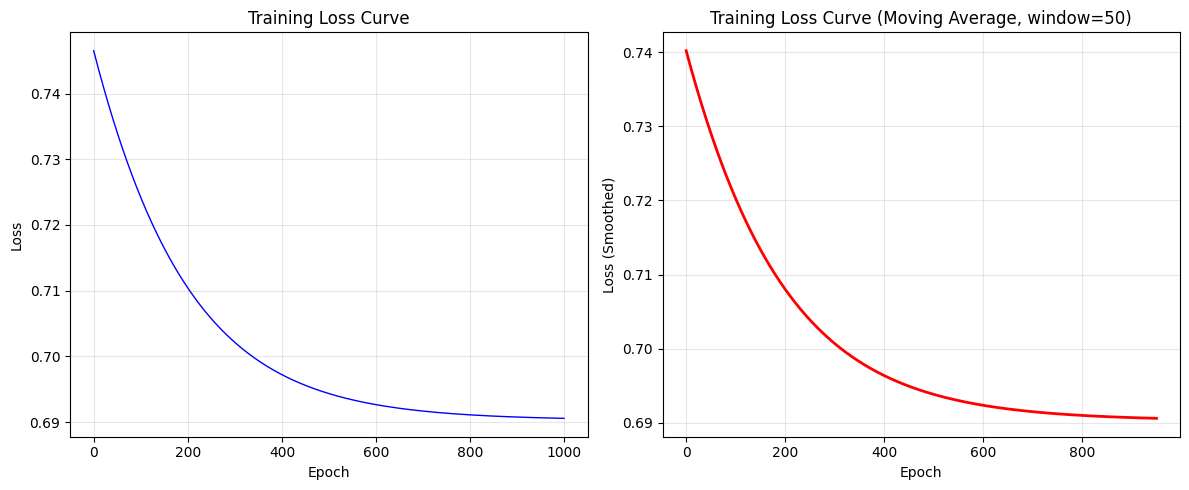


✅ Model Training Summary:
--------------------------------------------------
Total epochs:          1000
Final training loss:   0.690582
Training accuracy:     54.12%
Testing accuracy:      53.00%
Train-Test gap:        1.12%
--------------------------------------------------
✅ Model performance looks balanced!


In [ ]:
# ============================================================
# EXERCISE 3: Model Training
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

num_epochs = 1000
train_losses = []
epochs_list = []

print("📊 Training Configuration:")
print(f"   Number of epochs: {num_epochs}")
print(f"   Learning rate: {0.01}")
print(f"   Batch size: Full batch (all data)")
print("-" * 50)

print("\n🚀 Starting training...")
print("-" * 50)

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    epochs_list.append(epoch)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

print("\n✅ Training completed!")
print("-" * 50)

model.eval()

with torch.no_grad():
    train_predictions = model(X_train_tensor)
    test_predictions = model(X_test_tensor)

    train_predicted_labels = (train_predictions >= 0.5).float()
    test_predicted_labels = (test_predictions >= 0.5).float()

    train_correct = (train_predicted_labels == y_train_tensor).sum().item()
    train_total = y_train_tensor.size(0)
    train_accuracy = train_correct / train_total * 100

    test_correct = (test_predicted_labels == y_test_tensor).sum().item()
    test_total = y_test_tensor.size(0)
    test_accuracy = test_correct / test_total * 100

print("\n📊 Evaluation Results:")
print("-" * 50)
print(f"Training Accuracy: {train_accuracy:.2f}% ({train_correct}/{train_total} correct)")
print(f"Testing Accuracy:  {test_accuracy:.2f}% ({test_correct}/{test_total} correct)")
print("-" * 50)

# Calculate confusion matrix
with torch.no_grad():
    train_tp = ((train_predicted_labels == 1) & (y_train_tensor == 1)).sum().item()
    train_tn = ((train_predicted_labels == 0) & (y_train_tensor == 0)).sum().item()
    train_fp = ((train_predicted_labels == 1) & (y_train_tensor == 0)).sum().item()
    train_fn = ((train_predicted_labels == 0) & (y_train_tensor == 1)).sum().item()

    test_tp = ((test_predicted_labels == 1) & (y_test_tensor == 1)).sum().item()
    test_tn = ((test_predicted_labels == 0) & (y_test_tensor == 0)).sum().item()
    test_fp = ((test_predicted_labels == 1) & (y_test_tensor == 0)).sum().item()
    test_fn = ((test_predicted_labels == 0) & (y_test_tensor == 1)).sum().item()

print("\n📈 Additional Metrics:")
print("-" * 50)
print("Confusion Matrix (Training):")
print(f"   True Positives:  {train_tp}")
print(f"   True Negatives:  {train_tn}")
print(f"   False Positives: {train_fp}")
print(f"   False Negatives: {train_fn}")

print("\nConfusion Matrix (Testing):")
print(f"   True Positives:  {test_tp}")
print(f"   True Negatives:  {test_tn}")
print(f"   False Positives: {test_fp}")
print(f"   False Negatives: {test_fn}")

# Calculate metrics
def calculate_metrics(tp, tn, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

train_precision, train_recall, train_f1 = calculate_metrics(train_tp, train_tn, train_fp, train_fn)
test_precision, test_recall, test_f1 = calculate_metrics(test_tp, test_tn, test_fp, test_fn)

print("\nMetrics (Training):")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1 Score:  {train_f1:.4f}")

print("\nMetrics (Testing):")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1 Score:  {test_f1:.4f}")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_list, train_losses, 'b-', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)

# Smoothed loss curve
window_size = 50
smoothed_losses = np.convolve(train_losses, np.ones(window_size)/window_size, mode='valid')
plt.subplot(1, 2, 2)
plt.plot(range(len(smoothed_losses)), smoothed_losses, 'r-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (Smoothed)')
plt.title(f'Training Loss Curve (Moving Average, window={window_size})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Model Training Summary:")
print("-" * 50)
print(f"Total epochs:          {num_epochs}")
print(f"Final training loss:   {train_losses[-1]:.6f}")
print(f"Training accuracy:     {train_accuracy:.2f}%")
print(f"Testing accuracy:      {test_accuracy:.2f}%")
print(f"Train-Test gap:        {train_accuracy - test_accuracy:.2f}%")
print("-" * 50)

if train_accuracy - test_accuracy > 5:
    print("⚠️  Warning: There may be overfitting (training accuracy > test accuracy by > 5%)")
elif test_accuracy > train_accuracy:
    print("ℹ️  Note: Test accuracy is higher than training accuracy, which is unusual but possible")
else:
    print("✅ Model performance looks balanced!")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

optimizer_reg = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01)

num_epochs = 1000


for epoch in range(num_epochs):
    model.train()
    optimizer_reg.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer_reg.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

print("\nTraining completed!")
print("-" * 50)

model.eval()

with torch.no_grad():
    train_predictions = model(X_train_tensor)
    test_predictions = model(X_test_tensor)

    train_predicted = (train_predictions >= 0.5).float()
    test_predicted = (test_predictions >= 0.5).float()

    train_correct = (train_predicted == y_train_tensor).sum().item()
    train_total = y_train_tensor.size(0)
    train_accuracy = train_correct / train_total * 100

    test_correct = (test_predicted == y_test_tensor).sum().item()
    test_total = y_test_tensor.size(0)
    test_accuracy = test_correct / test_total * 100


print("\nOptimized Model Evaluation (with L2 Regularization):")
print("-" * 50)
print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")
print("-" * 50)

Epoch [100/1000], Loss: 0.690471
Epoch [200/1000], Loss: 0.690406
Epoch [300/1000], Loss: 0.690368
Epoch [400/1000], Loss: 0.690345
Epoch [500/1000], Loss: 0.690331
Epoch [600/1000], Loss: 0.690322
Epoch [700/1000], Loss: 0.690317
Epoch [800/1000], Loss: 0.690314
Epoch [900/1000], Loss: 0.690312
Epoch [1000/1000], Loss: 0.690311

Training completed!
--------------------------------------------------

Optimized Model Evaluation (with L2 Regularization):
--------------------------------------------------
Training Accuracy: 52.62%
Testing Accuracy: 54.50%
--------------------------------------------------


Retraining model with L2 regularization...
Epoch [100/1000], Loss: 0.727680
Epoch [200/1000], Loss: 0.712103
Epoch [300/1000], Loss: 0.702900
Epoch [400/1000], Loss: 0.697556
Epoch [500/1000], Loss: 0.694479
Epoch [600/1000], Loss: 0.692714
Epoch [700/1000], Loss: 0.691701
Epoch [800/1000], Loss: 0.691118
Epoch [900/1000], Loss: 0.690782
Epoch [1000/1000], Loss: 0.690588

Confusion Matrix - Training Set:
[[166 226]
 [137 271]]

Confusion Matrix - Testing Set:
[[44 54]
 [34 68]]

Training AUC: 0.5446
Testing AUC: 0.6116


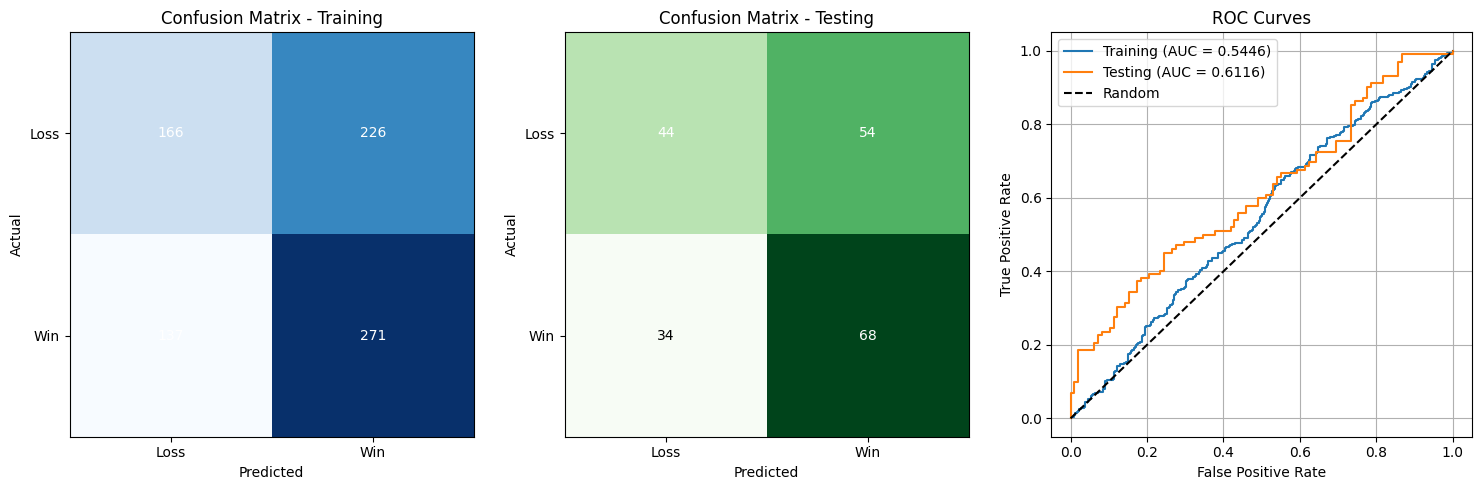

In [ ]:
# ============================================================
# EXERCISE 5: Visualization and Interpretation
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

print("Retraining model with L2 regularization...")
model = LogisticRegressionModel(input_dim)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01)
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_pred_binary = (train_preds >= 0.5).float()
    test_pred_binary = (test_preds >= 0.5).float()

    y_train_np = y_train_tensor.numpy()
    y_test_np = y_test_tensor.numpy()
    train_pred_np = train_pred_binary.numpy()
    test_pred_np = test_pred_binary.numpy()
    train_probs_np = train_preds.numpy()
    test_probs_np = test_preds.numpy()

cm_train = confusion_matrix(y_train_np, train_pred_np)
cm_test = confusion_matrix(y_test_np, test_pred_np)

print("\nConfusion Matrix - Training Set:")
print(cm_train)
print("\nConfusion Matrix - Testing Set:")
print(cm_test)

fpr_train, tpr_train, _ = roc_curve(y_train_np, train_probs_np)
auc_train = auc(fpr_train, tpr_train)
fpr_test, tpr_test, _ = roc_curve(y_test_np, test_probs_np)
auc_test = auc(fpr_test, tpr_test)

print(f"\nTraining AUC: {auc_train:.4f}")
print(f"Testing AUC: {auc_test:.4f}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

im1 = ax1.imshow(cm_train, cmap='Blues')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Loss', 'Win'])
ax1.set_yticklabels(['Loss', 'Win'])
ax1.set_title('Confusion Matrix - Training')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm_train[i, j]), ha='center', va='center', color='white' if cm_train[i, j] > cm_train.max()/2 else 'black')

im2 = ax2.imshow(cm_test, cmap='Greens')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Loss', 'Win'])
ax2.set_yticklabels(['Loss', 'Win'])
ax2.set_title('Confusion Matrix - Testing')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
# Add text annotations
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm_test[i, j]), ha='center', va='center', color='white' if cm_test[i, j] > cm_test.max()/2 else 'black')
ax3.plot(fpr_train, tpr_train, label=f'Training (AUC = {auc_train:.4f})')
ax3.plot(fpr_test, tpr_test, label=f'Testing (AUC = {auc_test:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', label='Random')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curves')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# EXERCISE 6: Model Saving and Loading
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

model_path = 'logistic_regression_model.pth'
torch.save(model.state_dict(), model_path)

print("=" * 60)
print("MODEL SAVING")
print("=" * 60)
print(f"✅ Model saved successfully as '{model_path}'")
print(f"Model parameters saved: {len(model.state_dict())} layers")
print(f"Keys in state_dict: {list(model.state_dict().keys())}")
print("\nModel parameter shapes:")
for name, param in model.state_dict().items():
    print(f"  {name}: {param.shape}")

loaded_model = LogisticRegressionModel(input_dim)
loaded_model.load_state_dict(torch.load(model_path))

print("\n" + "=" * 60)
print("MODEL LOADING")
print("=" * 60)
print(f"✅ Model loaded successfully from '{model_path}'")
print(f"Loaded parameters: {len(loaded_model.state_dict())} layers")
loaded_model.eval()

print("\n" + "=" * 60)
print("EVALUATING LOADED MODEL")
print("=" * 60)

with torch.no_grad():
    test_predictions = loaded_model(X_test_tensor)

    test_predicted = (test_predictions >= 0.5).float()

    correct = (test_predicted == y_test_tensor).sum().item()
    total = y_test_tensor.size(0)
    accuracy = correct / total * 100

print(f"Loaded Model Test Accuracy: {accuracy:.2f}% ({correct}/{total} correct)")

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)

with torch.no_grad():
    original_predictions = model(X_test_tensor)
    original_predicted = (original_predictions >= 0.5).float()
    original_correct = (original_predicted == y_test_tensor).sum().item()
    original_accuracy = original_correct / total * 100

print(f"Original Model Test Accuracy:  {original_accuracy:.2f}%")
print(f"Loaded Model Test Accuracy:    {accuracy:.2f}%")

if abs(original_accuracy - accuracy) < 0.01:
    print("\n✅ Model performance matches exactly!")
else:
    print(f"\n⚠️  Small difference detected: {abs(original_accuracy - accuracy):.2f}%")
    print("   (This could be due to floating point precision)")


print("\n" + "=" * 60)
print("PARAMETER VERIFICATION")
print("=" * 60)

params_match = True
for (name1, param1), (name2, param2) in zip(model.state_dict().items(), loaded_model.state_dict().items()):
    if not torch.equal(param1, param2):
        params_match = False
        print(f"❌ {name1}: Parameters do not match")
    else:
        print(f"✅ {name1}: Parameters match")

if params_match:
    print("\n✅ All model parameters match exactly!")
else:
    print("\n❌ Some parameters do not match")


print("\n" + "=" * 60)
print("✅ EXERCISE 6 COMPLETED SUCCESSFULLY")
print("=" * 60)
print("The loaded model is ready for deployment!")

MODEL SAVING
✅ Model saved successfully as 'logistic_regression_model.pth'
Model parameters saved: 2 layers
Keys in state_dict: ['linear.weight', 'linear.bias']

Model parameter shapes:
  linear.weight: torch.Size([1, 8])
  linear.bias: torch.Size([1])

MODEL LOADING
✅ Model loaded successfully from 'logistic_regression_model.pth'
Loaded parameters: 2 layers

EVALUATING LOADED MODEL
Loaded Model Test Accuracy: 56.00% (112/200 correct)

PERFORMANCE COMPARISON
Original Model Test Accuracy:  56.00%
Loaded Model Test Accuracy:    56.00%

✅ Model performance matches exactly!

PARAMETER VERIFICATION
✅ linear.weight: Parameters match
✅ linear.bias: Parameters match

✅ All model parameters match exactly!

✅ EXERCISE 6 COMPLETED SUCCESSFULLY
The loaded model is ready for deployment!


HYPERPARAMETER TUNING - LEARNING RATE OPTIMIZATION
Testing learning rates: [0.01, 0.05, 0.1]
Number of epochs per test: 100
------------------------------------------------------------

📊 Testing Learning Rate: 0.01
----------------------------------------
  Epoch [20/100], Loss: 0.725755
  Epoch [40/100], Loss: 0.722510
  Epoch [60/100], Loss: 0.719543
  Epoch [80/100], Loss: 0.716833
  Epoch [100/100], Loss: 0.714360

✅ Learning Rate 0.01: Test Accuracy = 49.00%

📊 Testing Learning Rate: 0.05
----------------------------------------
  Epoch [20/100], Loss: 0.713403
  Epoch [40/100], Loss: 0.704463
  Epoch [60/100], Loss: 0.698936
  Epoch [80/100], Loss: 0.695553
  Epoch [100/100], Loss: 0.693494

✅ Learning Rate 0.05: Test Accuracy = 48.00%

📊 Testing Learning Rate: 0.1
----------------------------------------
  Epoch [20/100], Loss: 0.715498
  Epoch [40/100], Loss: 0.699556
  Epoch [60/100], Loss: 0.693645
  Epoch [80/100], Loss: 0.691510
  Epoch [100/100], Loss: 0.690741

✅ Learnin

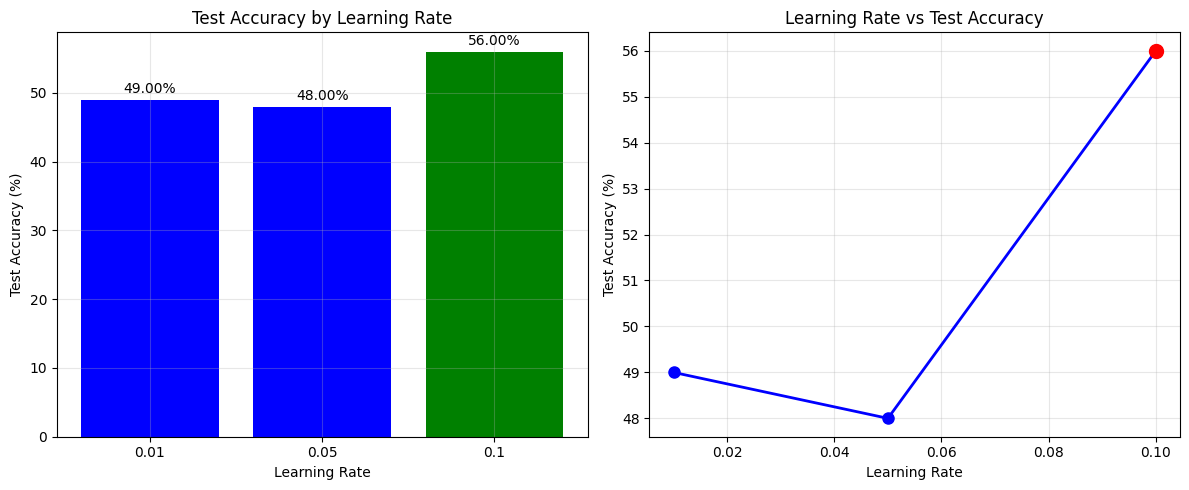


TRAINING FINAL MODEL WITH BEST LEARNING RATE
Training with best LR = 0.1 for 1000 epochs...
Epoch [100/1000], Loss: 0.690457
Epoch [200/1000], Loss: 0.690305
Epoch [300/1000], Loss: 0.690304
Epoch [400/1000], Loss: 0.690304
Epoch [500/1000], Loss: 0.690304
Epoch [600/1000], Loss: 0.690304
Epoch [700/1000], Loss: 0.690304
Epoch [800/1000], Loss: 0.690304
Epoch [900/1000], Loss: 0.690304
Epoch [1000/1000], Loss: 0.690304

FINAL MODEL PERFORMANCE
Best Learning Rate: 0.1
Training Accuracy: 52.25%
Testing Accuracy:  53.50%


In [ ]:
# ============================================================
# EXERCISE 7: Hyperparameter Tuning
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

learning_rates = [0.01, 0.05, 0.1]
num_epochs = 100

print("=" * 60)
print("HYPERPARAMETER TUNING - LEARNING RATE OPTIMIZATION")
print("=" * 60)
print(f"Testing learning rates: {learning_rates}")
print(f"Number of epochs per test: {num_epochs}")
print("-" * 60)

results = {}
best_lr = None
best_accuracy = 0
for lr in learning_rates:
    print(f"\n📊 Testing Learning Rate: {lr}")
    print("-" * 40)

    model_tune = LogisticRegressionModel(input_dim)
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model_tune.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model_tune.train()
        optimizer.zero_grad()
        outputs = model_tune(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0:
            print(f'  Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

    model_tune.eval()
    with torch.no_grad():
        test_predictions = model_tune(X_test_tensor)
        test_predicted = (test_predictions >= 0.5).float()
        correct = (test_predicted == y_test_tensor).sum().item()
        total = y_test_tensor.size(0)
        test_accuracy = correct / total * 100

    results[lr] = test_accuracy
    print(f"\n✅ Learning Rate {lr}: Test Accuracy = {test_accuracy:.2f}%")

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        best_lr = lr

print("\n" + "=" * 60)
print("TUNING RESULTS")
print("=" * 60)

print("\nLearning Rate Performance Summary:")
print("-" * 40)
for lr, acc in results.items():
    print(f"LR = {lr:5.2f}: Test Accuracy = {acc:.2f}%")

print("\n" + "-" * 40)
print(f"🏆 Best Learning Rate: {best_lr}")
print(f"🏆 Best Test Accuracy: {best_accuracy:.2f}%")
print("=" * 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
lrs = list(results.keys())
accs = list(results.values())
colors = ['blue' if lr != best_lr else 'green' for lr in lrs]
bars = ax1.bar([str(lr) for lr in lrs], accs, color=colors)
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Test Accuracy by Learning Rate')
ax1.grid(True, alpha=0.3)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom')

lrs_sorted = sorted(lrs)
accs_sorted = [results[lr] for lr in lrs_sorted]
ax2.plot(lrs_sorted, accs_sorted, 'bo-', linewidth=2, markersize=8)
ax2.scatter([best_lr], [best_accuracy], color='red', s=100, zorder=5)
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Learning Rate vs Test Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("TRAINING FINAL MODEL WITH BEST LEARNING RATE")
print("=" * 60)

final_model = LogisticRegressionModel(input_dim)
criterion = nn.BCELoss()
final_optimizer = optim.SGD(final_model.parameters(), lr=best_lr)

print(f"Training with best LR = {best_lr} for 1000 epochs...")

num_epochs_final = 1000
for epoch in range(num_epochs_final):
    final_model.train()
    final_optimizer.zero_grad()
    outputs = final_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    final_optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_final}], Loss: {loss.item():.6f}')

final_model.eval()
with torch.no_grad():
    final_train_preds = final_model(X_train_tensor)
    final_test_preds = final_model(X_test_tensor)

    final_train_pred_binary = (final_train_preds >= 0.5).float()
    final_test_pred_binary = (final_test_preds >= 0.5).float()

    train_correct = (final_train_pred_binary == y_train_tensor).sum().item()
    train_total = y_train_tensor.size(0)
    train_acc_final = train_correct / train_total * 100

    test_correct = (final_test_pred_binary == y_test_tensor).sum().item()
    test_total = y_test_tensor.size(0)
    test_acc_final = test_correct / test_total * 100

print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Best Learning Rate: {best_lr}")
print(f"Training Accuracy: {train_acc_final:.2f}%")
print(f"Testing Accuracy:  {test_acc_final:.2f}%")
print("=" * 60)

FEATURE IMPORTANCE EVALUATION

Model weights extracted:
Number of features: 8
Weight shape: (8,)
Bias: 0.039127

First 10 weights:
  Feature 0: 0.057149
  Feature 1: -0.021226
  Feature 2: 0.011473
  Feature 3: 0.065616
  Feature 4: 0.006288
  Feature 5: 0.050843
  Feature 6: -0.012211
  Feature 7: -0.056445

FEATURE IMPORTANCE RANKING

Top 10 Most Important Features:
--------------------------------------------------
     Feature    Weight  Abs_Weight
 gold_earned  0.065616    0.065616
       kills  0.057149    0.057149
damage_dealt -0.056445    0.056445
wards_placed  0.050843    0.050843
      deaths -0.021226    0.021226
wards_killed -0.012211    0.012211
     assists  0.011473    0.011473
          cs  0.006288    0.006288

Bottom 10 Least Important Features:
--------------------------------------------------
     Feature    Weight  Abs_Weight
 gold_earned  0.065616    0.065616
       kills  0.057149    0.057149
damage_dealt -0.056445    0.056445
wards_placed  0.050843    0.050843


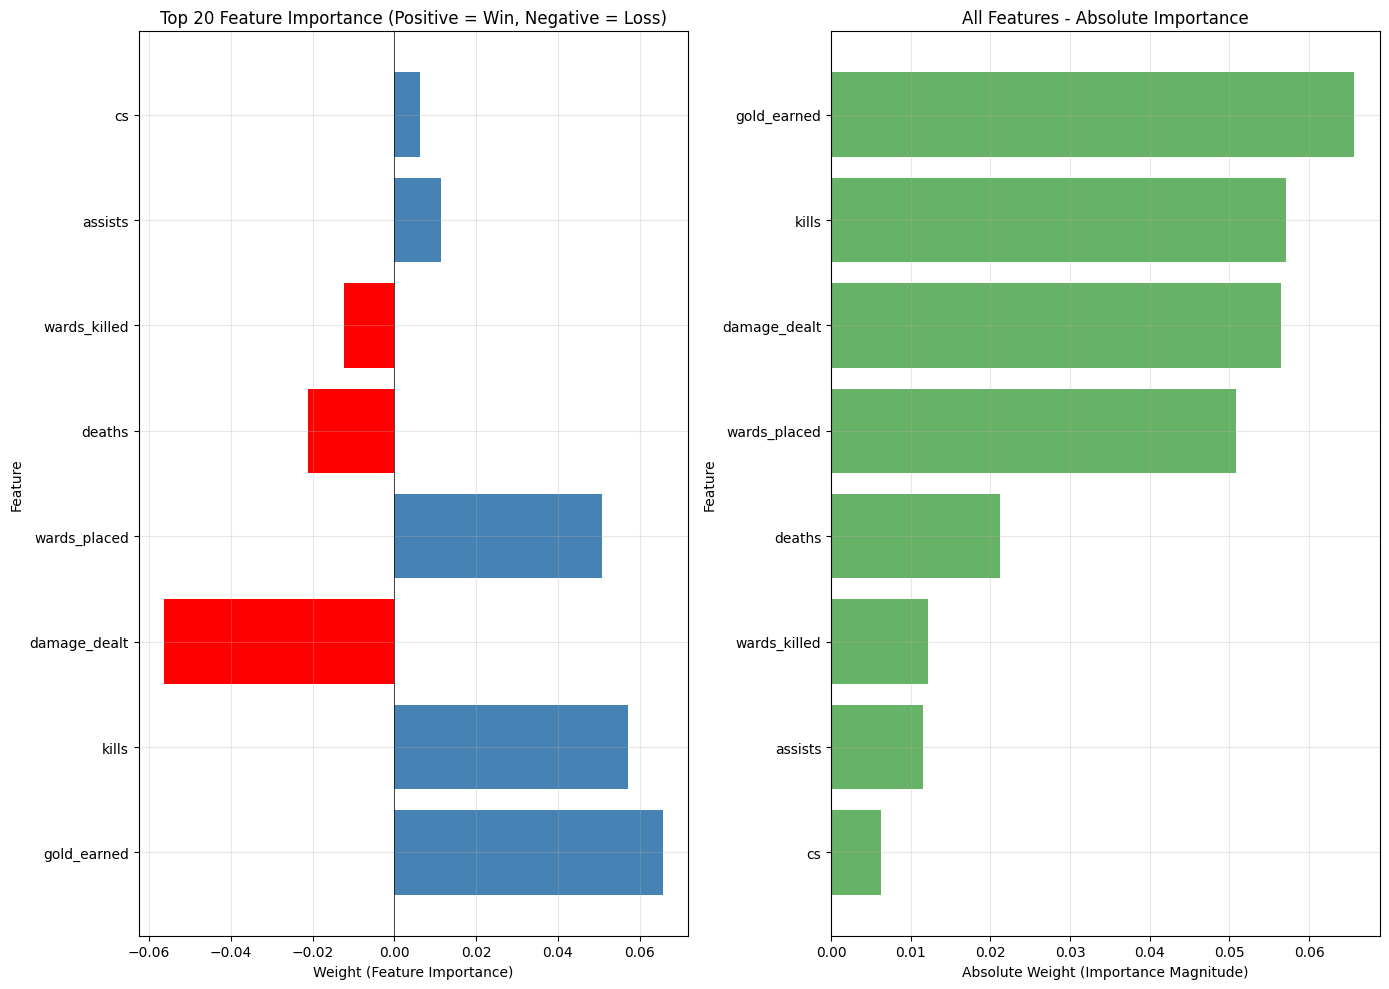

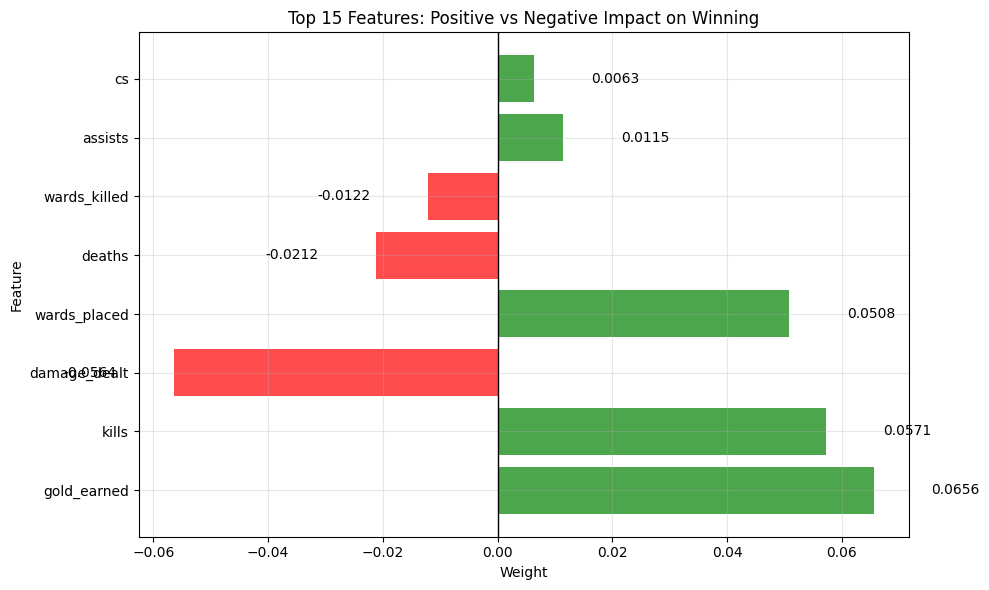


INTERPRETATION

🔵 Features with POSITIVE impact (correlated with winning):
--------------------------------------------------
  gold_earned              : +0.065616
  kills                    : +0.057149
  wards_placed             : +0.050843
  assists                  : +0.011473
  cs                       : +0.006288

🔴 Features with NEGATIVE impact (correlated with losing):
--------------------------------------------------
  damage_dealt             : -0.056445
  deaths                   : -0.021226
  wards_killed             : -0.012211

KEY INSIGHTS

📈 Most POSITIVE feature: gold_earned (Weight: 0.065616)
   → This feature strongly predicts a win

📉 Most NEGATIVE feature: damage_dealt (Weight: -0.056445)
   → This feature strongly predicts a loss

⭐ Most INFLUENTIAL feature: gold_earned (Abs Weight: 0.065616)
   → This feature has the largest overall impact on predictions

✅ Feature importance saved to 'feature_importance.csv'

FEATURE IMPORTANCE EVALUATION COMPLETE


In [ ]:
# ============================================================
# EXERCISE 8: Feature Importance Evaluation
# ============================================================

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("=" * 60)
print("FEATURE IMPORTANCE EVALUATION")
print("=" * 60)

model.eval()

weights = model.linear.weight.data.numpy().flatten()
bias = model.linear.bias.data.numpy()[0]

print(f"\nModel weights extracted:")
print(f"Number of features: {len(weights)}")
print(f"Weight shape: {weights.shape}")
print(f"Bias: {bias:.6f}")

print(f"\nFirst 10 weights:")
for i in range(min(10, len(weights))):
    print(f"  Feature {i}: {weights[i]:.6f}")

feature_names = X_train.columns.tolist()
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights,
    'Abs_Weight': np.abs(weights)
})

feature_importance_sorted = feature_importance.sort_values('Abs_Weight', ascending=False)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE RANKING")
print("=" * 60)
print("\nTop 10 Most Important Features:")
print("-" * 50)
print(feature_importance_sorted.head(10).to_string(index=False))

print("\nBottom 10 Least Important Features:")
print("-" * 50)
print(feature_importance_sorted.tail(10).to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(14, 10))

top_n = 20
top_features = feature_importance_sorted.head(top_n)

bars = axes[0].barh(top_features['Feature'], top_features['Weight'], color='steelblue')
colors = ['red' if w < 0 else 'steelblue' for w in top_features['Weight']]
bars = axes[0].barh(top_features['Feature'], top_features['Weight'], color=colors)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('Weight (Feature Importance)')
axes[0].set_ylabel('Feature')
axes[0].set_title(f'Top {top_n} Feature Importance (Positive = Win, Negative = Loss)')
axes[0].grid(True, alpha=0.3)

feature_importance_sorted_all = feature_importance.sort_values('Abs_Weight', ascending=True)
axes[1].barh(feature_importance_sorted_all['Feature'], feature_importance_sorted_all['Abs_Weight'],
             color='green', alpha=0.6)
axes[1].set_xlabel('Absolute Weight (Importance Magnitude)')
axes[1].set_ylabel('Feature')
axes[1].set_title('All Features - Absolute Importance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

top_15 = feature_importance_sorted.head(15)
colors = ['green' if w > 0 else 'red' for w in top_15['Weight']]

bars = ax.barh(top_15['Feature'], top_15['Weight'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Weight')
ax.set_ylabel('Feature')
ax.set_title('Top 15 Features: Positive vs Negative Impact on Winning')
ax.grid(True, alpha=0.3)

for bar, weight in zip(bars, top_15['Weight']):
    width = bar.get_width()
    label_x = width + (0.01 if width >= 0 else -0.01)
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'{weight:.4f}', va='center', ha='left' if width >= 0 else 'right')

plt.tight_layout()
plt.show()
print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
positive_features = feature_importance[feature_importance['Weight'] > 0].sort_values('Weight', ascending=False)
negative_features = feature_importance[feature_importance['Weight'] < 0].sort_values('Weight', ascending=True)

print(f"\n🔵 Features with POSITIVE impact (correlated with winning):")
print("-" * 50)
for i, row in positive_features.head(5).iterrows():
    print(f"  {row['Feature']:25s}: {row['Weight']:+.6f}")

print(f"\n🔴 Features with NEGATIVE impact (correlated with losing):")
print("-" * 50)
for i, row in negative_features.head(5).iterrows():
    print(f"  {row['Feature']:25s}: {row['Weight']:+.6f}")

print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

most_positive = feature_importance.loc[feature_importance['Weight'].idxmax()]
most_negative = feature_importance.loc[feature_importance['Weight'].idxmin()]
most_influential = feature_importance.loc[feature_importance['Abs_Weight'].idxmax()]

print(f"\n📈 Most POSITIVE feature: {most_positive['Feature']} (Weight: {most_positive['Weight']:.6f})")
print(f"   → This feature strongly predicts a win")
print(f"\n📉 Most NEGATIVE feature: {most_negative['Feature']} (Weight: {most_negative['Weight']:.6f})")
print(f"   → This feature strongly predicts a loss")
print(f"\n⭐ Most INFLUENTIAL feature: {most_influential['Feature']} (Abs Weight: {most_influential['Abs_Weight']:.6f})")
print(f"   → This feature has the largest overall impact on predictions")

feature_importance_sorted.to_csv('feature_importance.csv', index=False)
print(f"\n✅ Feature importance saved to 'feature_importance.csv'")

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE EVALUATION COMPLETE")
print("=" * 60)

In [ ]:
print("\n" + "="*60)
print("✅ ALL EXERCISES COMPLETED!")
print("="*60)
print("Exercise 1: Data Loading and Preprocessing - COMPLETE")
print("Exercise 2: Logistic Regression Model - COMPLETE")
print("Exercise 3: Model Training - COMPLETE")
print("Exercise 4: L2 Regularization - COMPLETE")
print("Exercise 5: Visualization - COMPLETE")
print("Exercise 6: Model Saving/Loading - COMPLETE")
print("Exercise 7: Hyperparameter Tuning - COMPLETE")
print("Exercise 8: Feature Importance - COMPLETE")
print("="*60)


✅ ALL EXERCISES COMPLETED!
Exercise 1: Data Loading and Preprocessing - COMPLETE
Exercise 2: Logistic Regression Model - COMPLETE
Exercise 3: Model Training - COMPLETE
Exercise 4: L2 Regularization - COMPLETE
Exercise 5: Visualization - COMPLETE
Exercise 6: Model Saving/Loading - COMPLETE
Exercise 7: Hyperparameter Tuning - COMPLETE
Exercise 8: Feature Importance - COMPLETE
